# Homework 5
## Holly Bossart
## Due 02/25/2020

## Problem 1 Solution


[[ 5.71460881]
 [ 2.98606949]
 [-0.27215695]]


<IPython.core.display.Javascript object>


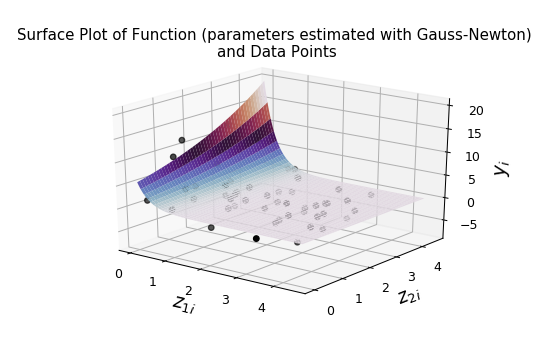

Text(0.5, 0, '$y_i$')

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
%matplotlib notebook

 
data = pd.read_csv('dataHW5-1.csv',delimiter=' ', header = 0, names = ["y", "z1", "z2"])
y = data['y'].to_numpy().reshape((50,1))
z1 = data['z1'].to_numpy().reshape((50,1))
z2 = data['z2'].to_numpy().reshape((50,1))
z = data[['z1','z2']].to_numpy().reshape((50,2))

tol = 1e-6
thzero = [0.5]
thone = [0.5]
thtwo = [0.5]

def f(theta0, theta1, theta2, z1, z2):
    f = []
    for i in range(len(y)):
        val = theta0*np.exp(-theta1*z1[i] - theta2*z2[i])
        f.append(val)
    f = np.asarray(f).reshape((50,1))
    return f


def a_calc(theta0, theta1, theta2, z1, z2):
    A = []
    for i in range(len(y)):
        partth0 = np.exp(-theta1*z1[i] - theta2*z2[i])
        partth1 = theta0*(-z1[i])*np.exp(-theta1*z1[i] - theta2*z2[i])
        partth2 = theta0*(-z2[i])*np.exp(-theta1*z1[i] - theta2*z2[i])
        val = np.asarray([partth0, partth1, partth2])
        A.append(val.T)
        
    A = np.asarray(A).reshape((50,3))
    return A

def x_calc(theta0, theta1, theta2, z1, z2):
    return y - f(theta0, theta1, theta2, z1, z2)

def update_theta(theta0, theta1, theta2, max_iterations):
    values = []
    theta = np.asarray([theta0, theta1, theta2]).reshape((3,1))
    num_iters = 0
    
    while(num_iters < max_iterations):
        A = a_calc(theta0, theta1, theta2, z1, z2)
        x = x_calc(theta0, theta1, theta2, z1, z2).reshape((50,1))
        inner = inv((A.T).dot(A))
        newtheta = theta + (inner.dot(A.T)).dot(x)
        values.append(newtheta)
        theta = newtheta
        theta0 = newtheta[0]
        thzero.append(theta0)
        theta1 = newtheta[1]
        thone.append(theta1)
        theta2 = newtheta[2]
        thtwo.append(theta2)
        num_iters += 1
        
    print(theta)
        
        
update_theta(-1, 1, -1, 100)


def plot(z1, z2):
    t0 = thzero[-1]
    t1 = thone[-1]
    t2 = thtwo[-1]
    
    return (t0*np.exp(-t1*z1 - t2*z2))

zones = np.linspace(0, 4.5, 200)
ztwos = np.linspace(0, 4.5, 200)
Z1, Z2 = np.meshgrid(zones, ztwos)
Y = plot(Z1, Z2)

fig = plt.figure()
ax = fig.gca(projection='3d')
s1 = ax.plot_surface(Z1, Z2, Y, cmap = 'twilight',label = 'Fitted curve using Gauss-Newton', antialiased=True)
pts = ax.scatter3D(z1, z2, y, c= 'k', label = 'Data points')
ax.set_title('Surface Plot of Function (parameters estimated with Gauss-Newton) \nand Data Points')

ax.set_xlabel('$z_{1i}$', fontsize=15, rotation=150)
ax.set_ylabel('$z_{2i}$',fontsize=15,)
ax.set_zlabel('$y_i$', fontsize=15)